# **Практическая работа №11. Работа с растровыми данными в Rasterio**

---

**Данные для обработки:**

- Одноканальное изображение (ЦМР): https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
- Мультиспектральное изображение (Landsat): https://github.com/opengeos/datasets/releases/download/raster/cog.tif

### **Задание 1. Чтение и исследование растровых данных**



1. Откройте одноканальное изображение ЦМР с использованием `rasterio`.


In [2]:
conda install rasterio

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - rasterio


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    affine-2.4.0               |  py313hca03da5_0          45 KB
    blosc-1.21.6               |       h7977b18_0          39 KB
    click-plugins-1.1.1        |     pyhd3eb1b0_0          10 KB
    cligj-0.7.2                |     pyhd3eb1b0_0          11 KB
    fmt-11.2.0                 |       h643473a_0         188 KB
    glib-2.86.3                |       h863a760_0         499 KB
    glib-tools-2.86.3          |       hff4a405_0          92 KB
    json-c-0.18                |       h254cc4a_0          70 KB
    libarchive-3.8.2           |       ha845c4f_0         761 KB
    libgdal-core-3.11.4        |       h6ecf920_0         8.8 MB

In [4]:
import urllib.request as u
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [5]:
dem_url="https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
cog_url="https://github.com/opengeos/datasets/releases/download/raster/cog.tif"

dem_fp="dem_90m.tif"
cog_fp="cog.tif"

In [8]:
dem = rasterio.open(dem_url)
cog = rasterio.open(cog_url)

2. Извлеките и выведите метаданные растра, включая СК, разрешение, границы, количество каналов и типы данных.


In [9]:
print("CRS:", dem.crs)
print("Resolution:", dem.res)
print("Bounds:", dem.bounds)
print("Bands:", dem.count)
print("Dtypes:", dem.dtypes)
print("Transform:", dem.transform)

CRS: EPSG:3857
Resolution: (90.0, 89.99579177642138)
Bounds: BoundingBox(left=-13442488.3428, bottom=4388214.6777, right=-13058278.3428, top=4668371.5775)
Bands: 1
Dtypes: ('int16',)
Transform: | 90.00, 0.00,-13442488.34|
| 0.00,-90.00, 4668371.58|
| 0.00, 0.00, 1.00|


3. Отобразите ширину и высоту растра, а также типы данных пикселей, чтобы понять размеры сетки и структуру данных.

In [10]:
print("Width:", dem.width, "Height:", dem.height)
print("Shape:", (dem.count, dem.height, dem.width))
print("Dtypes:", dem.dtypes)

Width: 4269 Height: 3113
Shape: (1, 3113, 4269)
Dtypes: ('int16',)


---



### **Задание 2. Визуализация и манипулирование растровыми каналами**



1. Визуализируйте одноканальное изображение ЦМР с использованием пользовательской цветовой карты (например, cmap='terrain').


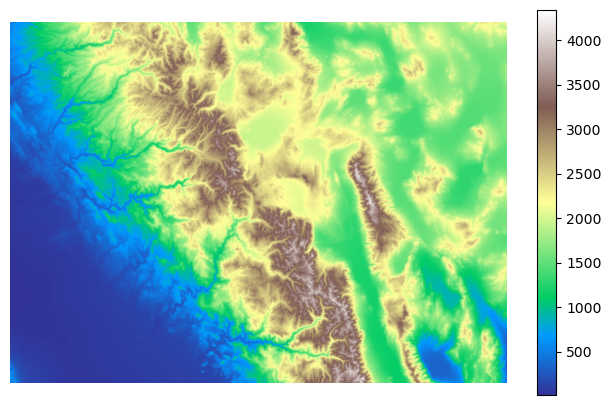

In [11]:
dem_arr=dem.read(1)
plt.figure(figsize=(8,5))
plt.imshow(dem_arr, cmap="terrain")
plt.colorbar()
plt.axis("off")
plt.show()

2. Откройте мультиспектральное изображение и визуализируйте первый канал с использованием подходящей цветовой карты.


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


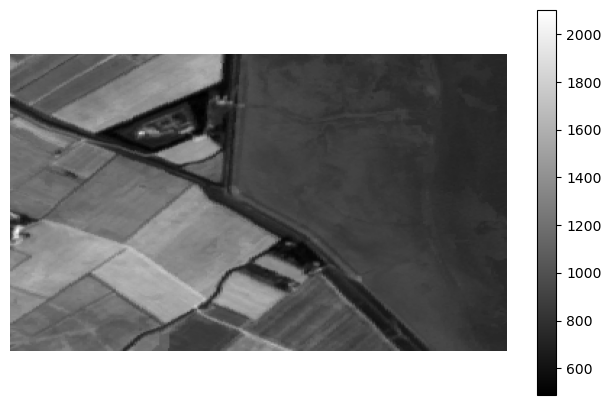

In [12]:
ms=rasterio.open(cog_fp)
b1=ms.read(1)
plt.figure(figsize=(8,5))
plt.imshow(b1, cmap="gray")
plt.colorbar()
plt.axis("off")
plt.show()

3. Объедините несколько каналов из мультиспектрального изображения (например, Красный, Зеленый и Синий) и совместите их в один массив для создания RGB-композитного изображения.

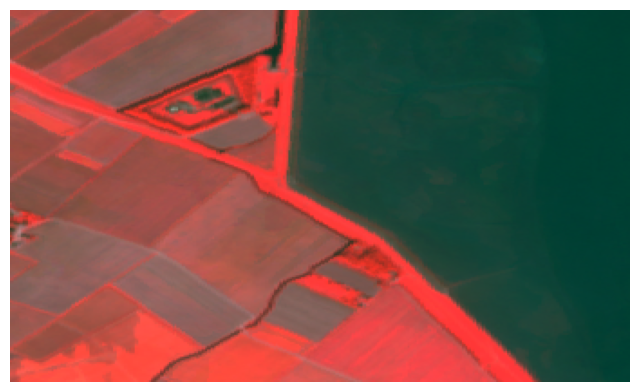

In [13]:
c=ms.count
r,g,b=((4,3,2) if c>=4 else (3,2,1))
rgb=np.stack([ms.read(r), ms.read(g), ms.read(b)], axis=-1).astype("float32")
p2,p98=np.percentile(rgb, (2,98))
rgb=np.clip((rgb-p2)/(p98-p2+1e-12), 0, 1)
plt.figure(figsize=(8,5))
plt.imshow(rgb)
plt.axis("off")
plt.show()

---



### **Задание 3. Обрезка растра с использованием индексации массива**



1. Откройте мультиспектральное изображение и обрежьте его с использованием спискового среза (указав диапазоны строк и столбцов).


In [14]:
arr=ms.read()

h,w=arr.shape[1],arr.shape[2]

r0=h//4
c0=w//4

s=min(512, h-r0, w-c0)

r1=r0+s
c1=c0+s

clipped=arr[:, r0:r1, c0:c1]
clipped.shape

(4, 155, 155)

2. Визуализируйте обрезанную часть изображения с использованием matplotlib, чтобы убедиться в корректном результате.


>*Примечание:*
>
> При работе с многоканальными растровыми изображениями, особенно в формате COG.TIFF (Cloud Optimized GeoTIFF), может возникнуть проблема с некорректным отображением псевдоцветного изображения. Это связано с тем, что разные каналы могут иметь различные диапазоны значений пикселей.
>
> Для корректной визуализации на шаге 2 необходимо применить нормализацию к каждому каналу перед отображением.



Включите следующую функцию в ваш код:

```python
# Функция для нормализации канала в диапазон от 0 до 1
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm
```

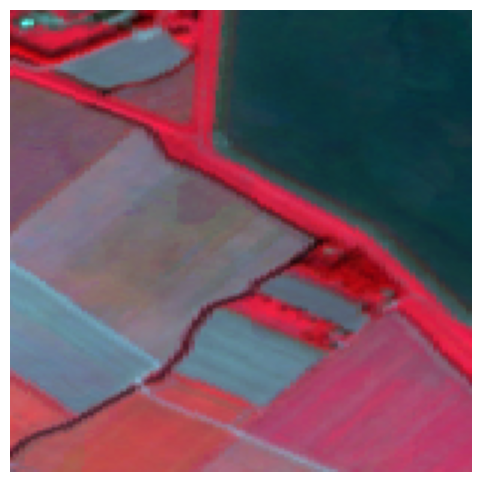

In [15]:
from rasterio.windows import Window

def normalize(band):
    band=band.astype("float32")
    mn,mx=band.min(),band.max()
    return (band-mn)/(mx-mn+1e-12)

c=clipped.shape[0]

r,g,b=((4,3,2) if c>=4 else (3,2,1))

rgb=np.stack([normalize(clipped[r-1]), normalize(clipped[g-1]), normalize(clipped[b-1])], axis=-1)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.axis("off")
plt.show()

3. Сохраните обрезанное подмножество растра в новый файл с именем `clipped_multispectral.tif`.

In [16]:
win=Window(c0, r0, c1-c0, r1-r0)

meta=ms.meta.copy()

meta.update(height=clipped.shape[1], width=clipped.shape[2], transform=ms.window_transform(win))

with rasterio.open("clipped_multispectral.tif","w",**meta) as dst:
    dst.write(clipped)

---



### **Задание 4. Вычисление NDWI (калькуляция каналов)**



1. Откройте мультиспектральное изображение и извлеките каналы Green (Зеленый) и Ближний инфракрасный (NIR).


In [17]:
c=ms.count

green,nir=((3,5) if c>=5 else ((2,4) if c>=4 else (1,1)))

G=ms.read(green).astype("float32")
N=ms.read(nir).astype("float32")

G.shape, N.shape

((206, 343), (206, 343))

2. Вычислите Нормализованный разностный водный индекс ([NDWI](https://en.wikipedia.org/wiki/Normalized_difference_water_index)) по формуле:

    NDWI = (Green - NIR) / (Green + NIR)

In [18]:
ndwi=(G-N)/(G+N+1e-12)
ndwi.min(), ndwi.max()

(np.float32(-0.6217617), np.float32(0.47722894))

3. Визуализируйте результат NDWI с использованием цветовой карты, подходящей для воды (например, cmap='Blues'), чтобы выделить водные объекты.


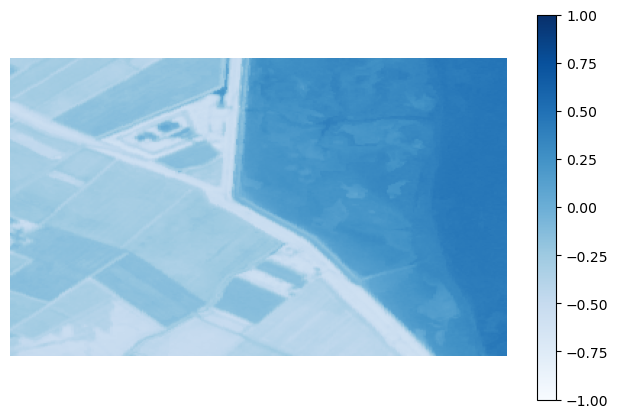

In [19]:
plt.figure(figsize=(8,5))
plt.imshow(ndwi, cmap="Blues", vmin=-1, vmax=1)
plt.colorbar()
plt.axis("off")
plt.show()



4. Сохраните полученное изображение NDWI как новый растровый файл с именем ndwi.tif.

In [20]:
meta=ms.meta.copy()
meta.update(count=1, dtype="float32")
with rasterio.open("ndwi.tif","w",**meta) as dst:
    dst.write(ndwi.astype("float32"), 1)

---



### **Задание 5. Перепроецирование растровых данных**



1. Перепроецируйте одноканальный растр ЦМР из его исходной СК в EPSG:4326 (WGS 84) с использованием функции `rasterio.warp.reproject`.


In [21]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

dst_crs="EPSG:4326"

transform,width,height=calculate_default_transform(dem.crs, dst_crs, dem.width, dem.height, *dem.bounds)

dst=np.empty((height,width), dtype=dem.dtypes[0])

reproject(
    source=rasterio.band(dem,1),
    destination=dst,
    src_transform=dem.transform,
    src_crs=dem.crs,
    dst_transform=transform,
    dst_crs=dst_crs,
    resampling=Resampling.bilinear
)

dst.shape

(2642, 4575)

2. Сохраните перепроецированный растр в новый файл GeoTIFF с именем `reprojected_dem.tif`.


In [22]:
meta=dem.meta.copy()

meta.update(crs=dst_crs, transform=transform, width=width, height=height)

with rasterio.open("reprojected_dem.tif","w",**meta) as out:
    out.write(dst, 1)

3. Визуализируйте как исходный, так и перепроецированный наборы данных ЦМР, чтобы сравнить, как перепроецирование влияет на пространственное покрытие и разрешение.

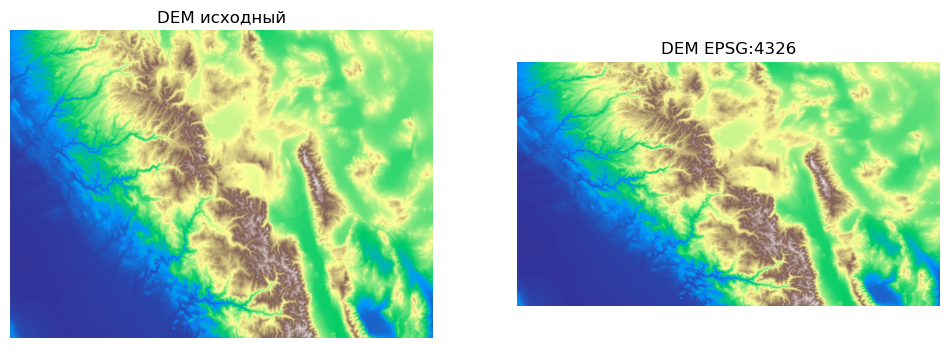

In [23]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(dem_arr, cmap="terrain")
plt.title("DEM исходный")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(dst, cmap="terrain")
plt.title("DEM EPSG:4326")
plt.axis("off")
plt.show()

---